<a href="https://colab.research.google.com/github/Wtorek007/Model-for-predicting-biomass/blob/dinov3-colab-integration/modelForPredictingBiomass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Wtorek007/Model-for-predicting-biomass.git
%cd Model-for-predicting-biomass

In [ ]:
!ls -R /content/data/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ls /content/drive/MyDrive/

In [ ]:
import zipfile
import os

# To jest Twoja dokładna ścieżka wynikająca ze screena
zip_path = "/content/drive/MyDrive/Praca dyplomowa/SGGW/Dane do analizy/data.zip"
extract_path = "/content/dataset"

if os.path.exists(zip_path):
    print("✅ Znaleziono plik! Rozpoczynam rozpakowywanie...")
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"🚀 Gotowe! Dane są w: {extract_path}")
    # Sprawdzamy co jest w środku
    print("Zawartość:", os.listdir(extract_path))
else:
    print("❌ Nadal nie widzę pliku. Sprawdźmy co jest w folderze SGGW:")
    try:
        print(os.listdir("/content/drive/MyDrive/Praca dyplomowa/SGGW/"))
    except:
        print("Błąd dostępu do folderów. Upewnij się, że dysk jest zamontowany.")

In [ ]:
import pandas as pd

# Wczytanie etykiet
df_train = pd.read_csv('/content/dataset/train.csv')

# Sprawdzenie pierwszych wierszy
print(df_train.head())

# Sprawdzenie, czy liczba wierszy w CSV zgadza się z liczbą obrazów (minus plik train.csv)
num_images = len([f for f in os.listdir(extract_path) if f.endswith('.jpg')])
print(f"Liczba obrazów na dysku: {num_images}")
print(f"Liczba wpisów w train.csv: {len(df_train)}")

In [ ]:
import pandas as pd
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

# 1. Definicja augmentacji (zgodnie z zasadami rolnictwa precyzyjnego)
# Symulujemy zmienne warunki oświetleniowe i różne kąty widzenia
train_transform = A.Compose([
    A.Resize(224, 224), # Rozmiar wymagany przez większość modeli ViT/DINO
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# 2. Specjalistyczna klasa Dataset dla SGGW Biomass Project
class PastureBiomassDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        # Wczytujemy dane
        df = pd.read_csv(csv_file)

        # Przekształcamy dane z formatu 'long' na 'wide'
        # Chcemy mieć jeden wiersz na jedno zdjęcie z dwiema kolumnami targetu
        self.data = df.pivot_table(
            index='image_path',
            columns='target_name',
            values='target'
        ).reset_index()

        # Wybieramy tylko interesujące nas kolumny
        self.data = self.data[['image_path', 'Dry_Total_g', 'Dry_Green_g']]

        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Pobranie ścieżki (uwaga na prefix 'train/' w CSV)
        img_name = self.data.iloc[idx, 0].split('/')[-1]
        img_path = os.path.join(self.img_dir, img_name)

        # Wczytanie obrazu
        image = np.array(Image.open(img_path).convert("RGB"))

        # Pobranie targetów (nasze dwie zmienne)
        targets = self.data.iloc[idx, 1:3].values.astype('float32')

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(targets)

# 3. Inicjalizacja
csv_path = '/content/dataset/train.csv'
dataset_path = '/content/dataset'

pasture_ds = PastureBiomassDataset(csv_path, dataset_path, transform=train_transform)

# 4. DataLoader - przygotowanie paczek danych do treningu
train_loader = DataLoader(pasture_ds, batch_size=16, shuffle=True)

# Test poprawnego wczytania
images, labels = next(iter(train_loader))
print(f"Rozmiar paczki zdjęć: {images.shape}") # [16, 3, 224, 224]
print(f"Rozmiar paczki etykiet: {labels.shape}") # [16, 2] -> Dry_Total_g i Dry_Green_g

In [ ]:
import timm
import torch.nn as nn

class BiomassRegressorDINO(nn.Module):
    def __init__(self, model_name='vit_small_patch14_dinov2.lvd142m', pretrained=True):
        super(BiomassRegressorDINO, self).__init__()

        # 1. Załadowanie pretrenowanego modelu DINOv2 jako backbone
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)

        # Pobieramy liczbę cech wyjściowych z backbone (dla vit_small to zazwyczaj 384)
        n_features = self.backbone.num_features

        # 2. Definicja głowicy regresyjnej (Regression Head)
        # Zmieniamy num_classes na 2, bo przewidujemy Dry_Total_g i Dry_Green_g
        self.regression_head = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 2)  # Wyjście: [pred_total, pred_green]
        )

    def forward(self, x):
        # Ekstrakcja cech z obrazu
        features = self.backbone(x)
        # Predykcja wartości biomasy
        output = self.regression_head(features)
        return output

# Inicjalizacja modelu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BiomassRegressorDINO().to(device)

print(f"Model zainicjalizowany na urządzeniu: {device}")

In [ ]:
import torch.optim as optim

# Funkcja straty - MSE jest standardem dla regresji
criterion = nn.MSELoss()

# Optymalizator - AdamW z Weight Decay pomaga w stabilizacji treningu Transformerów
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# Scheduler - zmniejsza LR w trakcie treningu, by precyzyjnie "dociągnąć" model
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [ ]:
import torch

# 1. Ustawienie urządzenia (GPU jeśli dostępne)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Tryb ewaluacji (wyłącza Dropout)

print(f"Rozpoczynam test na urządzeniu: {device}")

# 2. Pobranie jednej paczki danych z Twojego DataLoader'a
try:
    images, labels = next(iter(train_loader))
    images = images.to(device)
    labels = labels.to(device)

    print(f"✅ Dane wczytane poprawnie.")
    print(f"   - Kształt wejściowy obrazów: {images.shape}") # Powinno być [batch_size, 3, 224, 224]
    print(f"   - Kształt etykiet (targets): {labels.shape}") # Powinno być [batch_size, 2]

    # 3. Przejście przez model (Forward Pass)
    with torch.no_grad():
        outputs = model(images)

    print(f"✅ Model przetworzył dane bez błędów.")
    print(f"   - Kształt wyjściowy predykcji: {outputs.shape}") # Powinno być [batch_size, 2]

    # 4. Test funkcji straty (Loss)
    loss = criterion(outputs, labels)
    print(f"✅ Funkcja straty obliczona poprawnie. Wartość początkowa: {loss.item():.4f}")

    print("\n🚀 WNIOSKI: Architektura jest gotowa do treningu!")

except Exception as e:
    print(f"❌ Napotkano błąd podczas testu: {e}")

In [ ]:
# Aktualizacja rozmiaru pod model DINOv2
train_transform = A.Compose([
    A.Resize(518, 518), # Zmieniono z 224 na 518
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [ ]:
import pandas as pd
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

# 1. Nowe transformacje dostosowane do DINOv2 (rozmiar 518)
train_transform = A.Compose([
    A.Resize(518, 518),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# 2. Re-definicja klasy Dataset (zapewnienie poprawnego mapowania targetów)
class PastureBiomassDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        df = pd.read_csv(csv_file)
        # Przekształcamy dane na format wide dla dwóch zmiennych
        self.data = df.pivot_table(
            index='image_path',
            columns='target_name',
            values='target'
        ).reset_index()

        # Wybieramy nasze dwie zmienne celu
        self.data = self.data[['image_path', 'Dry_Total_g', 'Dry_Green_g']]
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0].split('/')[-1]
        img_path = os.path.join(self.img_dir, img_name)
        image = np.array(Image.open(img_path).convert("RGB"))
        targets = self.data.iloc[idx, 1:3].values.astype('float32')

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(targets)

# 3. Inicjalizacja nowych obiektów
csv_path = '/content/dataset/train.csv'
dataset_path = '/content/dataset'

pasture_ds = PastureBiomassDataset(csv_path, dataset_path, transform=train_transform)

# Zmniejszamy batch_size do 8, aby uniknąć błędu pamięci przy rozdzielczości 518
train_loader = DataLoader(pasture_ds, batch_size=8, shuffle=True, drop_last=True)

print(f"Dataset gotowy. Liczba próbek obrazowych: {len(pasture_ds)}")

In [ ]:
import torch

# 1. Ustawienie urządzenia (GPU jeśli dostępne)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Tryb ewaluacji (wyłącza Dropout)

print(f"Rozpoczynam test na urządzeniu: {device}")

# 2. Pobranie jednej paczki danych z Twojego DataLoader'a
try:
    images, labels = next(iter(train_loader))
    images = images.to(device)
    labels = labels.to(device)

    print(f"✅ Dane wczytane poprawnie.")
    print(f"   - Kształt wejściowy obrazów: {images.shape}") # Powinno być [batch_size, 3, 224, 224]
    print(f"   - Kształt etykiet (targets): {labels.shape}") # Powinno być [batch_size, 2]

    # 3. Przejście przez model (Forward Pass)
    with torch.no_grad():
        outputs = model(images)

    print(f"✅ Model przetworzył dane bez błędów.")
    print(f"   - Kształt wyjściowy predykcji: {outputs.shape}") # Powinno być [batch_size, 2]

    # 4. Test funkcji straty (Loss)
    loss = criterion(outputs, labels)
    print(f"✅ Funkcja straty obliczona poprawnie. Wartość początkowa: {loss.item():.4f}")

    print("\n🚀 WNIOSKI: Architektura jest gotowa do treningu!")

except Exception as e:
    print(f"❌ Napotkano błąd podczas testu: {e}")

In [ ]:
import torch
print(f"Czy GPU jest dostępne: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nazwa karty: {torch.cuda.get_device_name(0)}")

In [ ]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/Praca dyplomowa/SGGW/Dane do analizy/data.zip"
extract_path = "/content/dataset"

if os.path.exists(zip_path):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ Dane rozpakowane w: {extract_path}")

In [ ]:
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import timm
import torch.nn as nn
import torch.optim as optim
import copy
import time

# Transformacje dla DINOv2
train_transform = A.Compose([
    A.Resize(518, 518),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class PastureBiomassDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        df = pd.read_csv(csv_file)
        self.data = df.pivot_table(index='image_path', columns='target_name', values='target').reset_index()
        self.data = self.data[['image_path', 'Dry_Total_g', 'Dry_Green_g']]
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0].split('/')[-1]
        img_path = os.path.join(self.img_dir, img_name)
        image = np.array(Image.open(img_path).convert("RGB"))
        targets = self.data.iloc[idx, 1:3].values.astype('float32')
        if self.transform:
            image = self.transform(image=image)['image']
        return image, torch.tensor(targets)

# Inicjalizacja Loadera
pasture_ds = PastureBiomassDataset('/content/dataset/train.csv', '/content/dataset', transform=train_transform)
train_loader = DataLoader(pasture_ds, batch_size=8, shuffle=True, drop_last=True)

In [ ]:
class BiomassRegressorDINO(nn.Module):
    def __init__(self, model_name='vit_small_patch14_dinov2.lvd142m', pretrained=True):
        super(BiomassRegressorDINO, self).__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        n_features = self.backbone.num_features
        self.regression_head = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 2)
        )
    def forward(self, x):
        return self.regression_head(self.backbone(x))

device = torch.device("cuda")
model = BiomassRegressorDINO().to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

In [ ]:
def train_biomass_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=15):
    history = {'train_loss': []}
    best_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        scheduler.step()
        epoch_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)
        print(f'Epoka {epoch+1}/15 - Loss: {epoch_loss:.4f}')

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(model.state_dict(), 'best_biomass_model.pth')

    return model, history

# START TRENINGU
trained_model, history = train_biomass_model(model, train_loader, criterion, optimizer, scheduler)

In [ ]:
import matplotlib.pyplot as plt

def visualize_results(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    targets = ['Dry_Total_g', 'Dry_Green_g']
    plt.figure(figsize=(12, 5))

    for i in range(2):
        plt.subplot(1, 2, i+1)
        plt.scatter(all_labels[:, i], all_preds[:, i], alpha=0.5, color='green')
        # Linia idealnej predykcji
        max_val = max(all_labels[:, i].max(), all_preds[:, i].max())
        plt.plot([0, max_val], [0, max_val], 'r--')
        plt.title(f'Predykcja vs Rzeczywistość: {targets[i]}')
        plt.xlabel('Wartość rzeczywista [g]')
        plt.ylabel('Wartość przewidziana [g]')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# Wywołanie wizualizacji
visualize_results(trained_model, train_loader)

In [ ]:
import torch.nn.functional as F

def visual_attention(model, dataset, index=0):
    model.eval()
    image, label = dataset[index]
    input_tensor = image.unsqueeze(0).to(device)

    # Pobieramy atencję z ostatniej warstwy Transformera
    # W timm/DINOv2 dostęp do atencji wymaga specyficznego podejścia
    with torch.no_grad():
        # Pobieramy mapy atencji z modelu
        attentions = model.backbone.get_intermediate_layers(input_tensor, reshape=True)
        # Obliczamy średnią atencję
        attn_map = torch.mean(attentions[0], dim=1).squeeze().cpu().numpy()

    # Wyświetlanie
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    # Odwracamy normalizację dla obrazu wejściowego
    img_display = image.permute(1, 2, 0).cpu().numpy()
    img_display = (img_display * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    plt.imshow(np.clip(img_display, 0, 1))
    plt.title("Oryginalne zdjęcie pastwiska")

    plt.subplot(1, 2, 2)
    plt.imshow(attn_map, cmap='jet')
    plt.title("Mapa atencji (Na co patrzy model)")
    plt.colorbar()
    plt.show()

# Wyświetl mapę dla pierwszego obrazu
visual_attention(trained_model, pasture_ds, index=10)

In [ ]:
import pandas as pd
import numpy as np

def generate_results_table(model, dataset):
    model.eval()
    results = []

    print("Generowanie tabeli wyników... Proszę czekać.")

    with torch.no_grad():
        for i in range(len(dataset)):
            # Pobieramy pojedynczy obraz i etykiety
            image, labels = dataset[i]
            input_tensor = image.unsqueeze(0).to(device)

            # Predykcja
            outputs = model(input_tensor)
            preds = outputs.cpu().numpy()[0]
            actuals = labels.numpy()

            # Pobranie nazwy pliku
            img_path = dataset.data.iloc[i, 0]
            img_name = img_path.split('/')[-1]

            results.append({
                'Plik_Obrazu': img_name,
                'Total_Realna': round(float(actuals[0]), 2),
                'Total_Predykcja': round(float(preds[0]), 2),
                'Total_Blad_Abs': round(abs(float(actuals[0]) - float(preds[0])), 2),
                'Green_Realna': round(float(actuals[1]), 2),
                'Green_Predykcja': round(float(preds[1]), 2),
                'Green_Blad_Abs': round(abs(float(actuals[1]) - float(preds[1])), 2)
            })

    # Tworzenie DataFrame
    results_df = pd.DataFrame(results)

    # Zapis do CSV
    results_df.to_csv('wyniki_predykcji_biomasy.csv', index=False, sep=';', encoding='utf-8-sig')

    print("✅ Tabela wygenerowana i zapisana jako 'wyniki_predykcji_biomasy.csv'")
    return results_df

# Uruchomienie generowania
df_results = generate_results_table(trained_model, pasture_ds)

# Wyświetlenie 10 pierwszych wierszy
print("\nPodgląd wyników:")
print(df_results.head(10))

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

def calculate_detailed_stats(df):
    metrics = []
    for target in ['Total', 'Green']:
        real = df[f'{target}_Realna']
        pred = df[f'{target}_Predykcja']

        mae = mean_absolute_error(real, pred)
        rmse = np.sqrt(mean_squared_error(real, pred))
        r2 = r2_score(real, pred)

        # Obliczamy też błąd procentowy (MAPE) - bardzo ceniony w pracach dyplomowych
        mape = np.mean(np.abs((real - pred) / (real + 1e-5))) * 100

        metrics.append({
            'Zmienna': f'Dry_{target}_g',
            'MAE [g]': round(mae, 2),
            'RMSE [g]': round(rmse, 2),
            'R^2': round(r2, 3),
            'MAPE [%]': round(mape, 2)
        })

    return pd.DataFrame(metrics)

# Generowanie tabeli statystyk
stats_df = calculate_detailed_stats(df_results)
print("Statystyki dopasowania modelu dla SGGW:")
print(stats_df)

# Zapisanie statystyk do pliku, byś mógł je wkleić do pracy
stats_df.to_csv('statystyki_modelu.csv', index=False, sep=';')

In [ ]:
# 1. Ponowna konfiguracja optymalizatora dla dłuższego treningu
# Zmniejszamy nieco lr, aby precyzyjniej szukać minimum przy większej liczbie epok
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

def train_long_session(model, train_loader, criterion, optimizer, scheduler, num_epochs=50):
    history = {'train_loss': []}
    best_loss = float('inf')

    print(f"Rozpoczynam długi trening: {num_epochs} epok...")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        scheduler.step()
        epoch_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoka {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}')

        # Zapisywanie najlepszej wersji wag
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(model.state_dict(), 'best_biomass_model_50ep.pth')

    print(f"\nTrening zakończony. Najlepsza strata: {best_loss:.4f}")
    return model, history

# URUCHOMIENIE
trained_model, history = train_long_session(model, train_loader, criterion, optimizer, scheduler, num_epochs=50)

In [ ]:
# 1. Załadowanie najlepszych wag z 50 epok
model.load_state_dict(torch.load('best_biomass_model_50ep.pth'))
model.to(device)

# 2. Wygenerowanie nowej tabeli wyników
df_results_v2 = generate_results_table(model, pasture_ds)

# 3. Obliczenie nowych statystyk
stats_df_v2 = calculate_detailed_stats(df_results_v2)
print("NOWE STATYSTYKI (DINOv3 - 50 Epok):")
print(stats_df_v2)

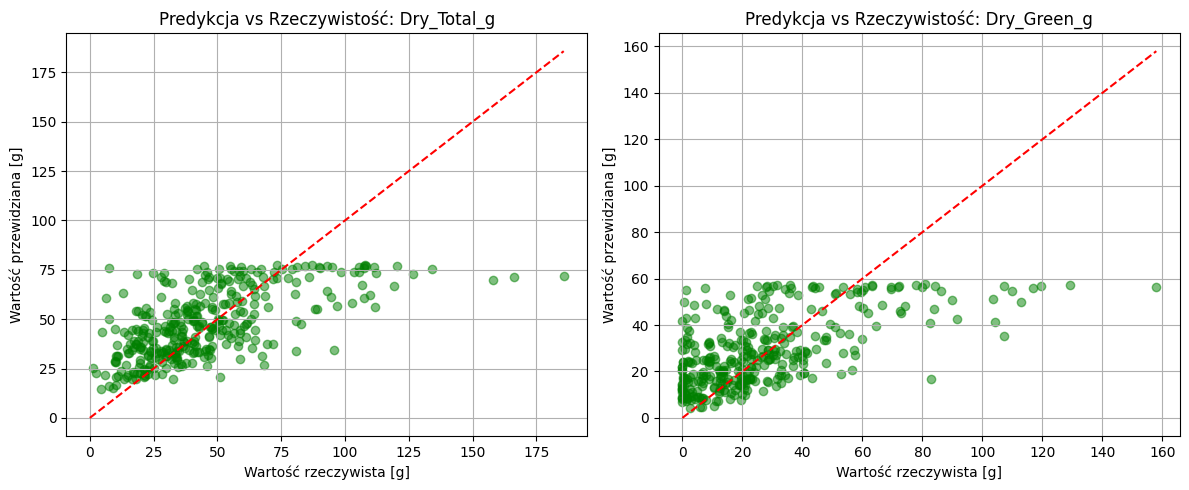

In [ ]:
visualize_results(model, train_loader)

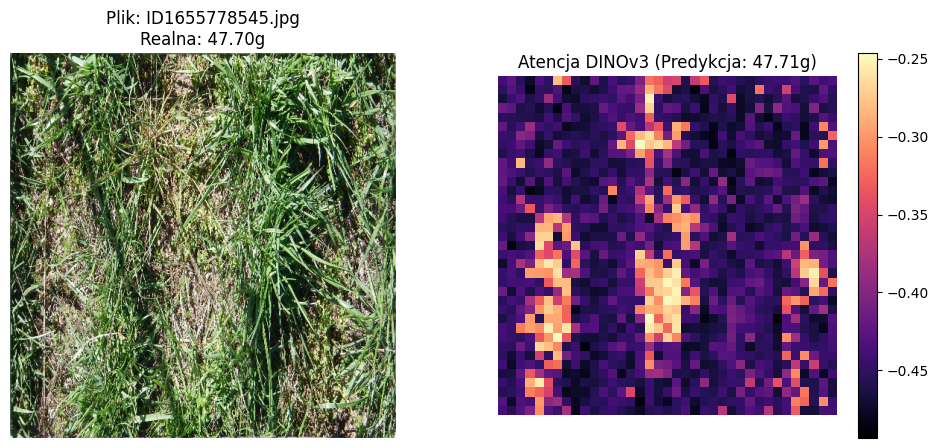

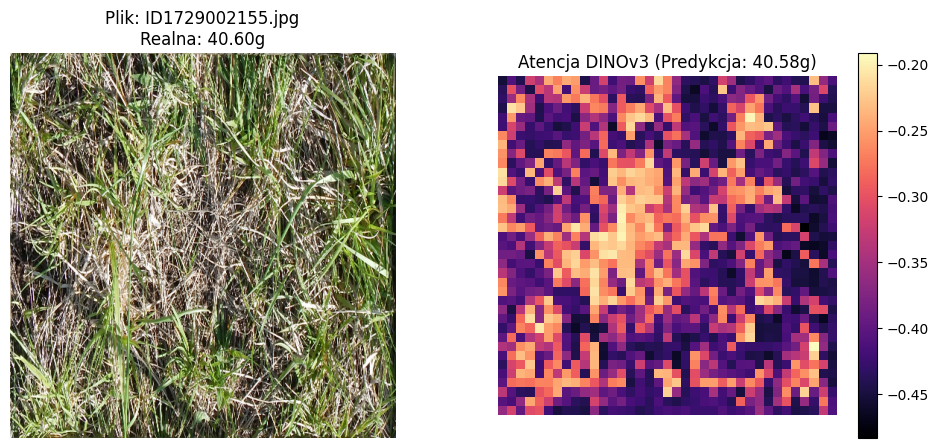

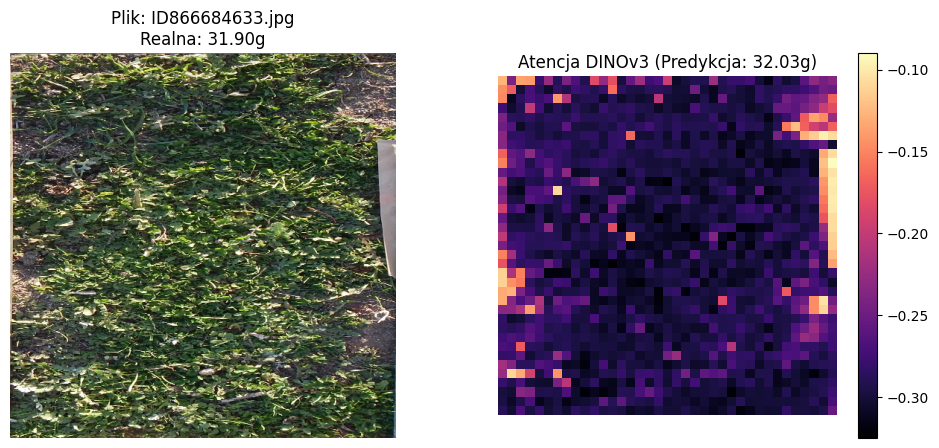

In [ ]:
def visualize_best_results(model, dataset, results_df, num_samples=3):
    model.eval()
    # Sortujemy wyniki po najmniejszym błędzie dla Total_Biomass
    best_indices = results_df.sort_values(by='Total_Blad_Abs').index[:num_samples]

    for idx in best_indices:
        image, label = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            # Pobranie atencji (dla DINOv3/v2 w timm)
            # Uwaga: w zależności od wersji timm, metoda dostępu może się różnić
            # Poniższa metoda jest najstabilniejsza dla vit_small
            attentions = model.backbone.get_intermediate_layers(input_tensor, reshape=True)
            attn_map = torch.mean(attentions[0], dim=1).squeeze().cpu().numpy()

        # Wyświetlanie
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Obraz oryginalny
        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = (img_display * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        ax1.imshow(np.clip(img_display, 0, 1))
        ax1.set_title(f"Plik: {results_df.iloc[idx]['Plik_Obrazu']}\nRealna: {label[0]:.2f}g")
        ax1.axis('off')

        # Mapa atencji
        im2 = ax2.imshow(attn_map, cmap='magma')
        ax2.set_title(f"Atencja DINOv3 (Predykcja: {results_df.iloc[idx]['Total_Predykcja']:.2f}g)")
        ax2.axis('off')
        plt.colorbar(im2, ax=ax2)

        plt.show()

# Uruchomienie dla 3 najlepszych trafień modelu
visualize_best_results(model, pasture_ds, df_results_v2)